# Resource Estimation for Max-K-Cut QAOA Models

Compares the seven QAOA model variants by **circuit cost** rather than output quality:
2-qubit gate counts, 2-qubit depth, qubit-interaction structure, scaling with problem
size, and a quality-vs-cost Pareto view.

Counts are reported at two levels:

- **Logical** — native RZZ/RXX/RYY interactions of the untranspiled reps=1 ansatz
  (all-to-all connectivity). The Dicke initial state (`qc.initialize`) is decomposed
  to CX-level so its 2-qubit gates are counted.
- **Hardware** — after transpiling to `FakeBrisbane` (127-qubit heavy-hex Eagle;
  native 2-qubit gate is ECR, counted by arity not name), `optimization_level=3`,
  seeded transpiler, parameters unbound. The gap between the two levels is the
  routing/SWAP + basis-translation overhead.

**Note:** *XY Mixer (no agg)* runs the **identical circuit** to *XY Mixer* — only the
CVaR aggregation differs — so the two share all resource metrics (one bar in the bar
charts, two points in the Pareto plot).

In [1]:
# --- Path setup ---
import sys
import os
import time
from math import comb
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "max_k_cut").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import qiskit
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

from max_k_cut import (
    generate_graph,
    tight_qubo_penalty, tight_rqubo_penalty,
    build_model_circuits, decompose_for_counting,
    logical_metrics, hardware_metrics, interaction_counts,
    rebuild_experiment_graphs,
)

warnings.filterwarnings('ignore', category=DeprecationWarning)
%config InlineBackend.figure_format = 'retina'
plt.rcParams["lines.linewidth"] = 2.25

# --- Experiment parameters (match generate_results.ipynb) ---
K = 3
NUM_NODES = 5
REPS = 1
SEED = 42
T_REP = 0.0   # representative penalty (tight), matching the "(Tight)" quality column

data_dir = os.path.join(os.getcwd(), "Data")
TAG = "Noisy_Results_P1_random_init_10_graphs_cvar_violations"
RAW_SAMPLES_PKL = os.path.join(data_dir, "raw_samples_Noisy_P1_random_init_10_graphs_cvar.pkl")

MODEL_COLORS = {
    "QUBO": "#0077BB",
    "RQUBO": "#EE7733",
    "Dicke QUBO": "#228833",
    "Dicke RQUBO": "#009988",
    # display aliases (hyphenated labels used in figure legends)
    "R-QUBO": "#EE7733",
    "Dicke R-QUBO": "#009988",
    "Penalty+Mixer QUBO": "#EE3377",
    "XY Mixer": "#CC3311",
    "XY Mixer (no agg)": "#56B4E9",
}
# XY Mixer (no agg) shares XY Mixer's circuit -> six distinct circuits
DISTINCT_MODELS = ["QUBO", "RQUBO", "Dicke QUBO", "Dicke RQUBO", "Penalty+Mixer QUBO", "XY Mixer"]
SEGMENTS = ["init", "cost", "mixer"]

backend = FakeBrisbane()
print("qiskit version:", qiskit.__version__)
print("backend:", backend.name, "| qubits:", backend.num_qubits,
      "| 2q basis gate:", [g for g in backend.operation_names if g in ("ecr", "cx", "cz")])

qiskit version: 1.4.6
backend: fake_brisbane | qubits: 127 | 2q basis gate: ['ecr']


## Rebuild the experiment graphs

The exact 10 Erdős–Rényi graphs from the experiments are reconstructed from the edge
lists stored in the raw-samples pickle (no RNG replay needed).

In [2]:
graphs = rebuild_experiment_graphs(RAW_SAMPLES_PKL, num_nodes=NUM_NODES)
num_graphs = len(graphs)
assert num_graphs == 10 and all(G.number_of_nodes() == NUM_NODES for G in graphs)

for g, G in enumerate(graphs):
    isolated = [v for v in G.nodes if G.degree(v) == 0]
    print(f"graph {g}: |E| = {G.number_of_edges():2d}"
          + (f", isolated nodes: {isolated}" if isolated else ""))

graph 0: |E| =  4, isolated nodes: [4]
graph 1: |E| =  4
graph 2: |E| =  4, isolated nodes: [4]
graph 3: |E| =  3, isolated nodes: [0]
graph 4: |E| =  5
graph 5: |E| =  5
graph 6: |E| =  8
graph 7: |E| =  4, isolated nodes: [2]
graph 8: |E| =  3, isolated nodes: [1]
graph 9: |E| =  9


## Penalty-value independence

The *set* of two-qubit interactions does not depend on the penalty interpolation
parameter $t$ — only the rotation angles change — with one exception: an **isolated
node has tight penalty 0**, so its $\binom{K}{2}$ within-node penalty terms vanish at
$t=0$ and reappear for $t>0$. Since the Pareto plot below uses the *(Tight)* quality
column, resources are computed at $t=0$, i.e. exactly the circuits that ran there.

In [3]:
for name, pen_fn, cols in [("QUBO", tight_qubo_penalty, K),
                           ("RQUBO", tight_rqubo_penalty, K - 1)]:
    for g, G in enumerate(graphs):
        n_zero_pen = int(np.sum(pen_fn(G, K) == 0))
        c0 = logical_metrics(build_model_circuits(name, G, K, t=0.0)["cost"])["twoq_count"]
        c1 = logical_metrics(build_model_circuits(name, G, K, t=1.0)["cost"])["twoq_count"]
        assert c1 - c0 == comb(cols, 2) * n_zero_pen, (name, g, c0, c1, n_zero_pen)
print("Penalty-structure check passed: t=0 vs t=1 counts differ only by the "
      "within-node terms of zero-tight-penalty (isolated) nodes.")

Penalty-structure check passed: t=0 vs t=1 counts differ only by the within-node terms of zero-tight-penalty (isolated) nodes.


## Compute resource metrics

For each of the 10 experiment graphs and each distinct circuit: logical 2-qubit
count per segment (init / cost / mixer), logical 2-qubit depth, and the same after
seeded transpilation to FakeBrisbane (segments recovered via labeled barriers;
hardware depth is reported for the full circuit only, since per-segment depth is
ill-defined after routing).

In [4]:
t0 = time.time()
metrics = {}
for name in DISTINCT_MODELS:
    rec = {k: [] for k in [
        "num_qubits",
        "logical_init", "logical_cost", "logical_mixer", "logical_total", "logical_depth",
        "hw_init", "hw_cost", "hw_mixer", "hw_total", "hw_depth",
    ]}
    for G in graphs:
        circs = build_model_circuits(name, G, K, t=T_REP)
        rec["num_qubits"].append(circs["num_qubits"])
        for seg in SEGMENTS:
            rec[f"logical_{seg}"].append(logical_metrics(circs[seg])["twoq_count"])
        lm = logical_metrics(circs["full"])
        rec["logical_total"].append(lm["twoq_count"])
        rec["logical_depth"].append(lm["twoq_depth"])
        hw = hardware_metrics(circs["full"], backend, seed=SEED)
        for seg in SEGMENTS:
            rec[f"hw_{seg}"].append(hw[f"{seg}_twoq"])
        rec["hw_total"].append(hw["twoq_count"])
        rec["hw_depth"].append(hw["twoq_depth"])
    metrics[name] = {k: np.array(v) for k, v in rec.items()}
print(f"computed in {time.time() - t0:.0f} s\n")

print(f"{'model':22s} {'qubits':>6s} {'logical 2q':>11s} {'hardware 2q':>12s} "
      f"{'logical 2q depth':>17s} {'hw 2q depth':>12s}")
for name in DISTINCT_MODELS:
    m = metrics[name]
    print(f"{name:22s} {m['num_qubits'][0]:6d} "
          f"{m['logical_total'].mean():8.1f} ± {m['logical_total'].std():4.1f} "
          f"{m['hw_total'].mean():8.1f} ± {m['hw_total'].std():5.1f} "
          f"{m['logical_depth'].mean():10.1f} ± {m['logical_depth'].std():4.1f} "
          f"{m['hw_depth'].mean():8.1f} ± {m['hw_depth'].std():5.1f}")

computed in 14 s

model                  qubits  logical 2q  hardware 2q  logical 2q depth  hw 2q depth
QUBO                       15     28.2 ±  6.9    116.8 ±  29.7       14.2 ±  3.2     61.3 ±  16.4
RQUBO                      10     24.1 ±  8.0     81.9 ±  33.2       12.8 ±  2.7     56.4 ±  20.4
Dicke QUBO                 15     48.2 ±  6.9    172.6 ±  41.9       18.2 ±  3.2     81.8 ±  20.4
Dicke RQUBO                10     34.1 ±  8.0     98.5 ±  36.0       14.8 ±  2.7     59.3 ±  20.2
Penalty+Mixer QUBO         15     78.2 ±  6.9    255.1 ±  51.3       24.2 ±  3.2    104.7 ±  28.4
XY Mixer                   15     64.7 ±  5.8    200.8 ±  45.3       14.0 ±  1.3     80.7 ±  22.6


In [5]:
# Sanity checks against closed-form counts
for g, G in enumerate(graphs):
    E = G.number_of_edges()
    nz_q = int(np.count_nonzero(tight_qubo_penalty(G, K)))
    nz_r = int(np.count_nonzero(tight_rqubo_penalty(G, K)))
    assert metrics["QUBO"]["logical_cost"][g] == K * E + comb(K, 2) * nz_q
    assert metrics["Dicke QUBO"]["logical_cost"][g] == metrics["QUBO"]["logical_cost"][g]
    assert metrics["RQUBO"]["logical_cost"][g] == (K - 1) ** 2 * E + comb(K - 1, 2) * nz_r
    assert metrics["Dicke RQUBO"]["logical_cost"][g] == metrics["RQUBO"]["logical_cost"][g]
    assert metrics["XY Mixer"]["logical_cost"][g] == K * E

assert (metrics["QUBO"]["num_qubits"] == NUM_NODES * K).all()
assert (metrics["RQUBO"]["num_qubits"] == NUM_NODES * (K - 1)).all()
assert (metrics["Dicke RQUBO"]["num_qubits"] == NUM_NODES * (K - 1)).all()
# Reduced-Dicke prep: (K-2) cry + (K-2) cx per node; X mixer has no 2q gates
assert (metrics["Dicke RQUBO"]["logical_init"] == 2 * (K - 2) * NUM_NODES).all()
assert (metrics["Dicke RQUBO"]["logical_mixer"] == 0).all()
assert (metrics["XY Mixer"]["logical_mixer"] == 2 * K * NUM_NODES).all()
assert (metrics["Penalty+Mixer QUBO"]["logical_mixer"] == 2 * K * NUM_NODES).all()
assert (metrics["QUBO"]["logical_init"] == 0).all() and (metrics["QUBO"]["logical_mixer"] == 0).all()
for name in DISTINCT_MODELS:
    assert (metrics[name]["hw_total"] >= metrics[name]["logical_total"]).all()
print("Sanity checks passed.")

Sanity checks passed.


## Figure 1 — 2-qubit gate count and depth per model

Gate counts are stacked by circuit segment (initial state / cost layer / mixer
layer); error bars show the std of the total over the 10 graphs. Depth panels show
the full-circuit 2-qubit depth.

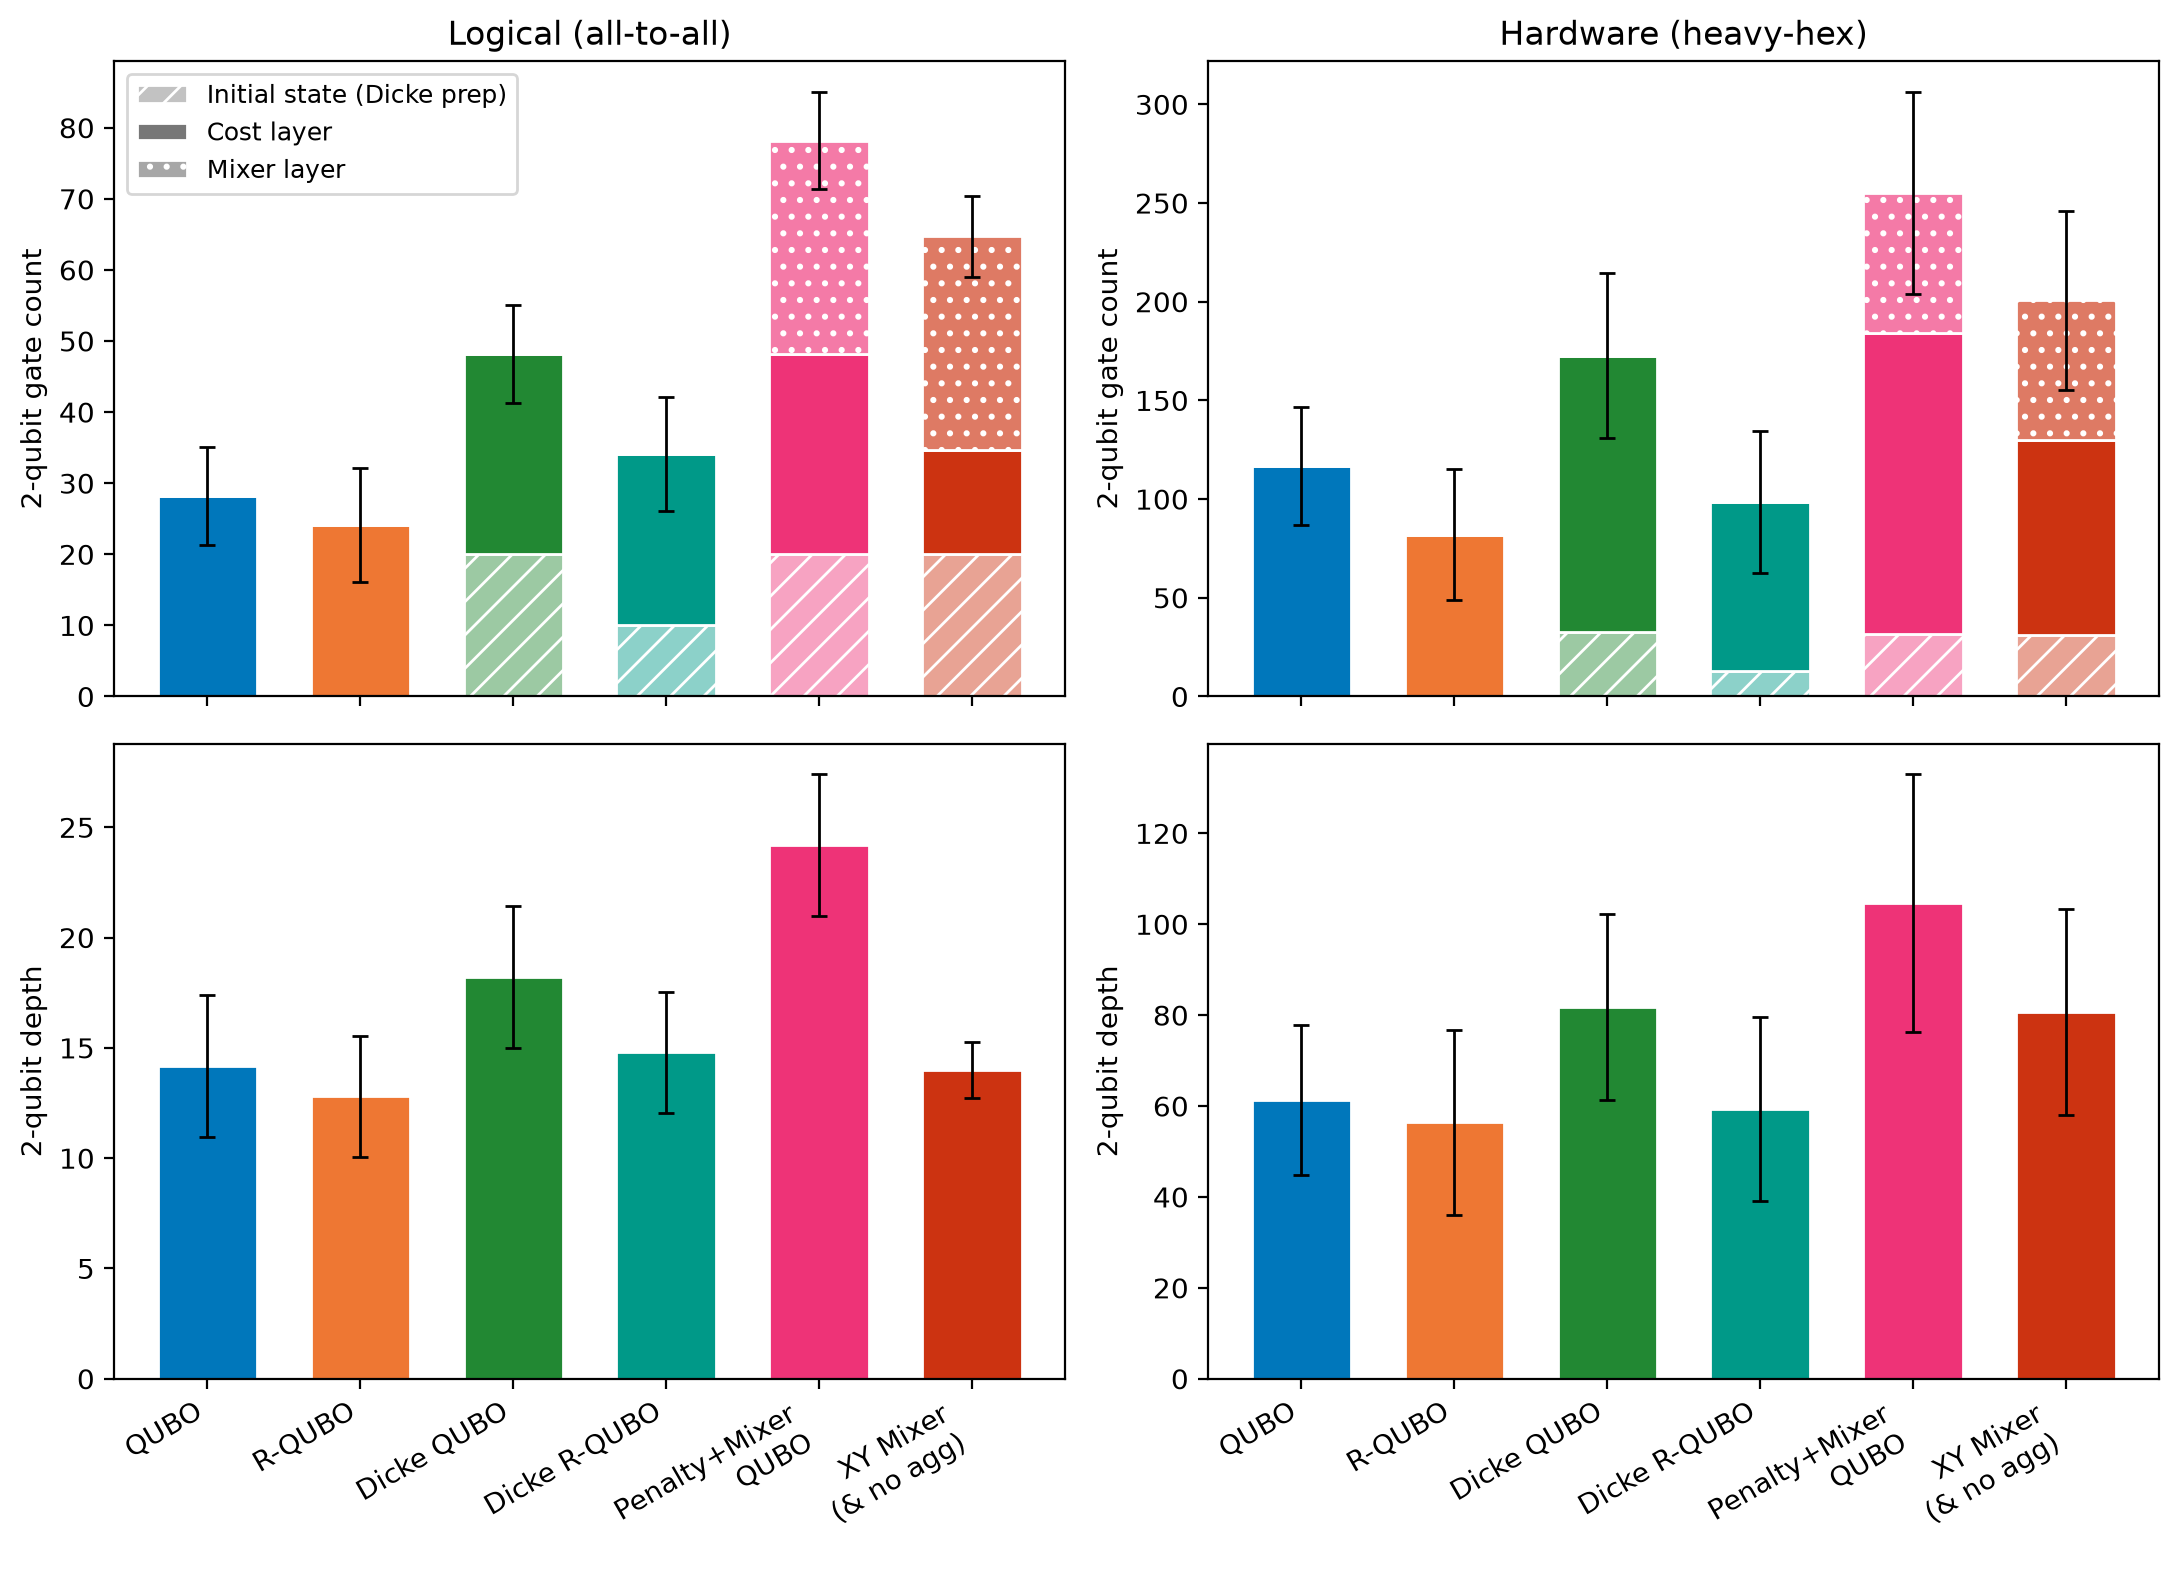

In [6]:
def tint(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

SEG_STYLE = {"init": (0.55, "//"), "cost": (0.0, None), "mixer": (0.35, "..")}
SEG_LABEL = {"init": "Initial state (Dicke prep)", "cost": "Cost layer", "mixer": "Mixer layer"}

bar_labels = ["QUBO", "R-QUBO", "Dicke QUBO", "Dicke R-QUBO", "Penalty+Mixer\nQUBO", "XY Mixer\n(& no agg)"]
x = np.arange(len(DISTINCT_MODELS))

fig, axs = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

for ax, level, title in [(axs[0, 0], "logical", "Logical (all-to-all)"),
                         (axs[0, 1], "hw", "Hardware (heavy-hex)")]:
    bottom = np.zeros(len(DISTINCT_MODELS))
    for seg in SEGMENTS:
        vals = np.array([metrics[m][f"{level}_{seg}"].mean() for m in DISTINCT_MODELS])
        amount, hatch = SEG_STYLE[seg]
        ax.bar(x, vals, bottom=bottom,
               color=[tint(MODEL_COLORS[m], amount) for m in DISTINCT_MODELS],
               hatch=hatch, edgecolor="white", linewidth=1.0, width=0.65)
        bottom += vals
    stds = np.array([metrics[m][f"{level}_total"].std() for m in DISTINCT_MODELS])
    ax.errorbar(x, bottom, yerr=stds, fmt="none", ecolor="black", capsize=3, linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("2-qubit gate count")

seg_handles = [Patch(facecolor=tint("#777777", SEG_STYLE[s][0]), hatch=SEG_STYLE[s][1],
                     edgecolor="white", label=SEG_LABEL[s]) for s in SEGMENTS]
axs[0, 0].legend(handles=seg_handles, loc="upper left", fontsize=9)

for ax, level in [(axs[1, 0], "logical"), (axs[1, 1], "hw")]:
    vals = np.array([metrics[m][f"{level}_depth"].mean() for m in DISTINCT_MODELS])
    stds = np.array([metrics[m][f"{level}_depth"].std() for m in DISTINCT_MODELS])
    ax.bar(x, vals, color=[MODEL_COLORS[m] for m in DISTINCT_MODELS],
           edgecolor="white", linewidth=1.0, width=0.65)
    ax.errorbar(x, vals, yerr=stds, fmt="none", ecolor="black", capsize=3, linewidth=1)
    ax.set_ylabel("2-qubit depth")
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=30, ha="right")

plt.tight_layout()
fig.savefig(os.path.join("Data", f"resource_stacked_bars_{TAG}.pdf"), bbox_inches="tight")
plt.show()

## Figure 2 — Qubit interaction graphs (logical level, graph 0)

Qubit $x_{i,j}$ (node $i$, partition $j$) is drawn at row $i$, column $j$, so the
one-hot block structure is visible: **horizontal/arced edges within a row** are
penalty or XY-mixer terms inside one node's partition register, **edges between
rows** are cost terms between graph nodes (and Dicke-prep CX gates within a row).
Edge width and darkness are proportional to the number of 2-qubit gates on that
pair, on a shared scale across panels.

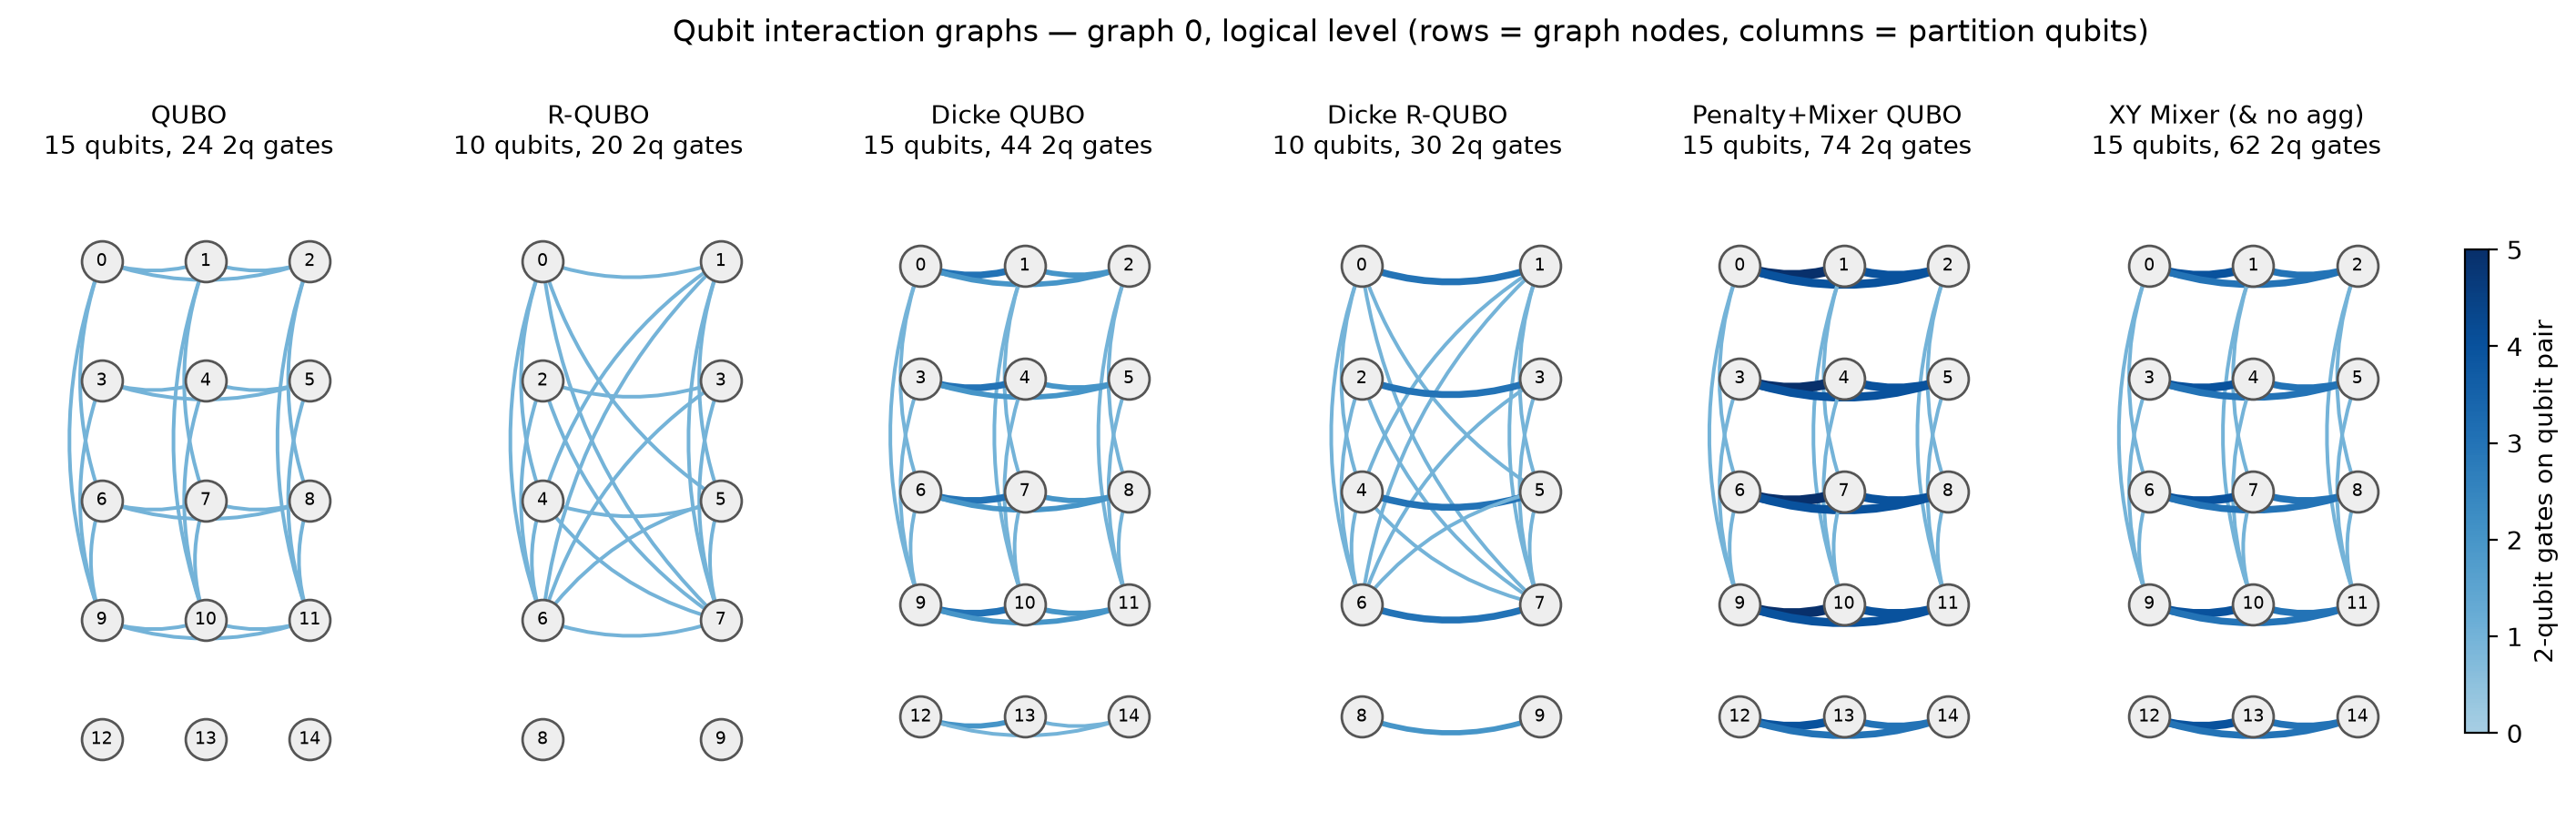

In [7]:
g_show = 0
G0 = graphs[g_show]

int_counts = {}
for name in DISTINCT_MODELS:
    circs = build_model_circuits(name, G0, K, t=T_REP)
    int_counts[name] = interaction_counts(decompose_for_counting(circs["full"]))
vmax = max(max(c.values()) for c in int_counts.values())

# Truncated single-hue sequential map so the lightest edges stay visible
cmap = mcolors.LinearSegmentedColormap.from_list(
    "blues_trunc", plt.cm.Blues(np.linspace(0.35, 1.0, 256)))
norm = mcolors.Normalize(vmin=0, vmax=vmax)

fig, axs = plt.subplots(1, len(DISTINCT_MODELS), figsize=(3.4 * len(DISTINCT_MODELS), 4.6))

for ax, name in zip(axs, DISTINCT_MODELS):
    counts = int_counts[name]
    nq = metrics[name]["num_qubits"][0]
    ncols = K - 1 if name in ("RQUBO", "Dicke RQUBO") else K
    pos = {q: (q % ncols, -(q // ncols)) for q in range(nq)}
    H = nx.Graph()
    H.add_nodes_from(range(nq))
    for (a, b), c in counts.items():
        H.add_edge(a, b, count=c)
    edges = list(H.edges)
    widths = [0.8 + 3.2 * H.edges[e]["count"] / vmax for e in edges]
    ecolors = [cmap(norm(H.edges[e]["count"])) for e in edges]
    # arc the edges so collinear vertical cost edges don't overlap
    nx.draw_networkx_edges(H, pos, edgelist=edges, ax=ax, width=widths,
                           edge_color=ecolors, connectionstyle="arc3,rad=0.18",
                           arrows=True, arrowstyle="-", node_size=260)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=260,
                           node_color="#EEEEEE", edgecolors="#555555")
    nx.draw_networkx_labels(H, pos, ax=ax, font_size=7)
    title = "XY Mixer (& no agg)" if name == "XY Mixer" else name.replace("RQUBO", "R-QUBO")
    ax.set_title(f"{title}\n{nq} qubits, {sum(counts.values())} 2q gates", fontsize=10)
    ax.set_axis_off()
    ax.margins(0.15)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axs, shrink=0.75, pad=0.02, label="2-qubit gates on qubit pair")
fig.suptitle(f"Qubit interaction graphs — graph {g_show}, logical level "
             f"(rows = graph nodes, columns = partition qubits)", y=1.06)
fig.savefig(os.path.join("Data", f"resource_interaction_graphs_{TAG}.pdf"), bbox_inches="tight")
plt.show()

## Figure 3 — Scaling with problem size

2-qubit gate count vs number of graph nodes $n$ (at $K=3$) and vs number of
partitions $K$ (at $n=5$), on synthetic Erdős–Rényi graphs ($p=0.5$, unweighted,
3 seeds per point, mean shown). Solid = hardware (FakeBrisbane), dashed = logical.
Bottom row: qubit count ($n \cdot K$ for all one-hot models, $n \cdot (K-1)$ for RQUBO).

Note: at $K=2$ the ring XY mixer degenerates — the 2-qubit ring visits the same
pair twice, so each node gets 4 mixer gates instead of 2.

In [8]:
N_SWEEP = list(range(3, 11))
K_SWEEP = [2, 3, 4, 5]
SWEEP_SEEDS = [0, 1, 2]
EDGE_PROB = 0.5

def sweep_point(name, n, k, seed):
    G = generate_graph(n, EDGE_PROB, weighted=False, seed=seed)
    tries = 0
    while G.number_of_edges() == 0:
        tries += 1
        G = generate_graph(n, EDGE_PROB, weighted=False, seed=seed + 1000 * tries)
    circs = build_model_circuits(name, G, k, t=T_REP)
    lg = logical_metrics(circs["full"])["twoq_count"]
    hw = hardware_metrics(circs["full"], backend, seed=SEED)["twoq_count"]
    return circs["num_qubits"], lg, hw

t0 = time.time()
sweep = {}
for name in DISTINCT_MODELS:
    for axis, values, fixed in [("n", N_SWEEP, K), ("k", K_SWEEP, NUM_NODES)]:
        qs, lgs, hws = [], [], []
        for v in values:
            n, k = (v, fixed) if axis == "n" else (fixed, v)
            pts = [sweep_point(name, n, k, s) for s in SWEEP_SEEDS]
            qs.append(np.mean([p[0] for p in pts]))
            lgs.append(np.mean([p[1] for p in pts]))
            hws.append(np.mean([p[2] for p in pts]))
        sweep[(name, axis)] = {"qubits": np.array(qs),
                               "logical": np.array(lgs),
                               "hardware": np.array(hws)}
    print(f"{name} done ({time.time() - t0:.0f} s)")

QUBO done (3 s)


RQUBO done (6 s)


Dicke QUBO done (13 s)


Dicke RQUBO done (19 s)


Penalty+Mixer QUBO done (27 s)


XY Mixer done (36 s)


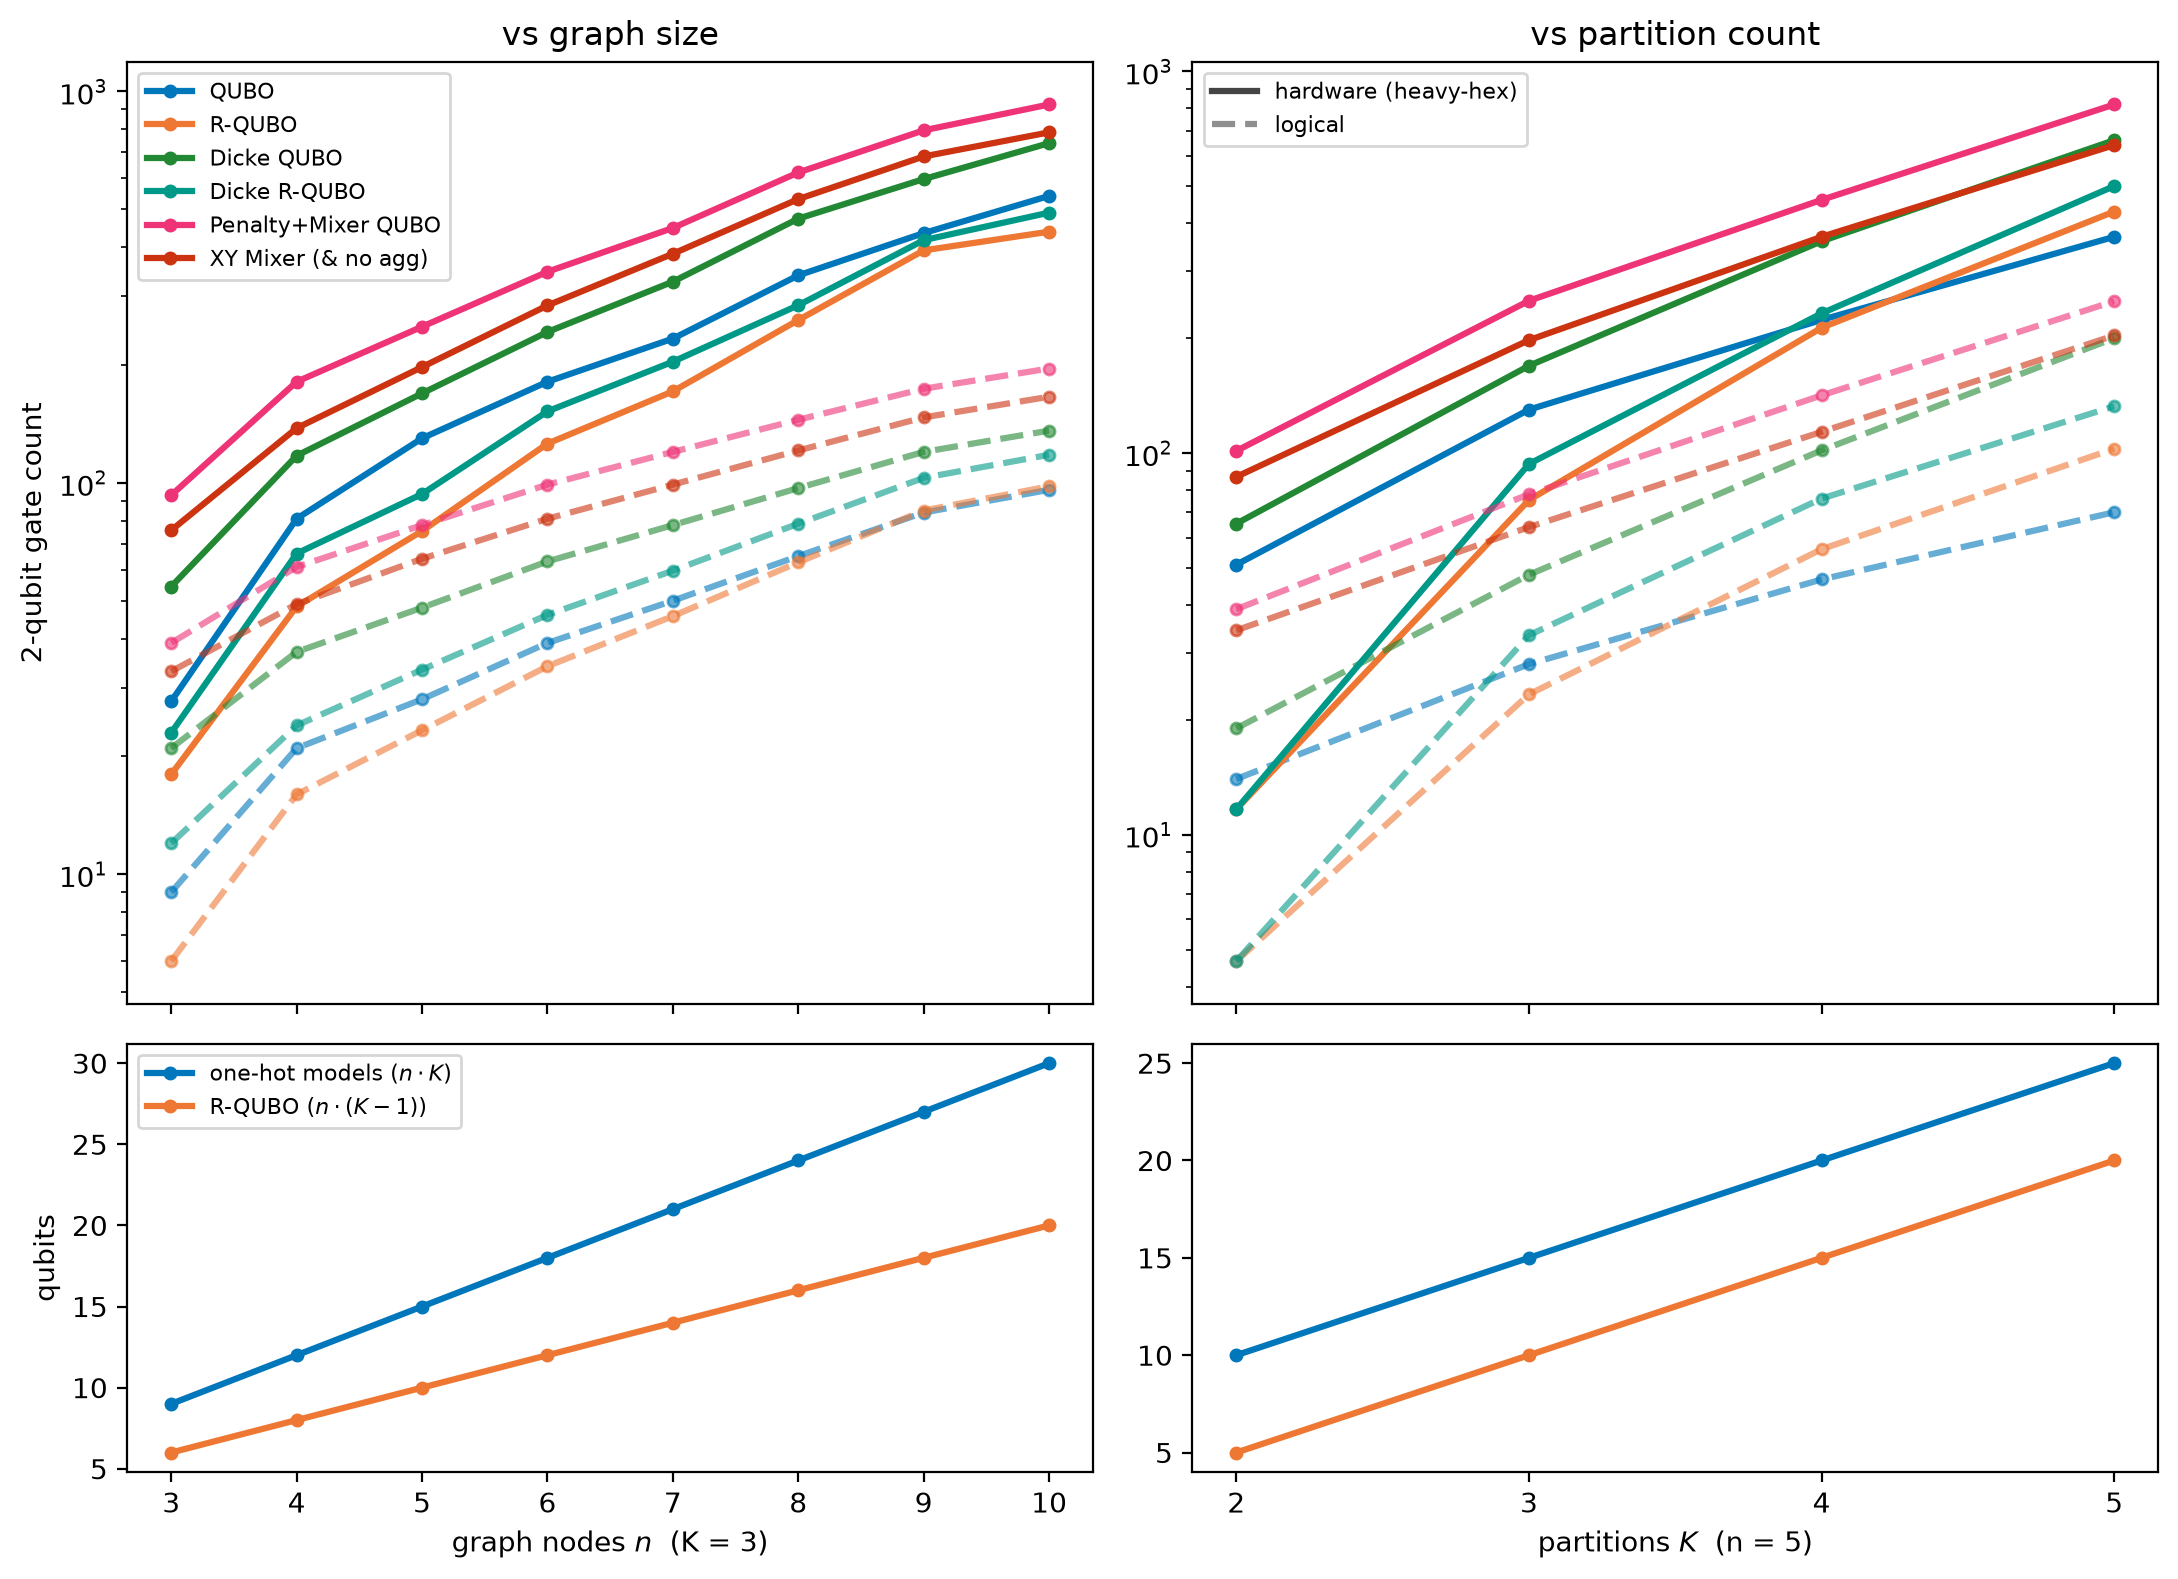

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(11, 8), sharex="col",
                        gridspec_kw={"height_ratios": [2.2, 1]})

for col, (axis, values, xlabel) in enumerate([("n", N_SWEEP, "graph nodes $n$  (K = 3)"),
                                              ("k", K_SWEEP, "partitions $K$  (n = 5)")]):
    ax = axs[0, col]
    for name in DISTINCT_MODELS:
        s = sweep[(name, axis)]
        ax.plot(values, s["hardware"], "-", color=MODEL_COLORS[name],
                marker="o", markersize=4)
        ax.plot(values, s["logical"], "--", color=MODEL_COLORS[name],
                marker="o", markersize=4, alpha=0.6)
    ax.set_yscale("log")
    ax.set_ylabel("2-qubit gate count" if col == 0 else "")
    ax.set_title(f"vs {'graph size' if axis == 'n' else 'partition count'}")

    axq = axs[1, col]
    axq.plot(values, sweep[("QUBO", axis)]["qubits"], "-", color=MODEL_COLORS["QUBO"],
             marker="o", markersize=4, label="one-hot models ($n \\cdot K$)")
    axq.plot(values, sweep[("RQUBO", axis)]["qubits"], "-", color=MODEL_COLORS["RQUBO"],
             marker="o", markersize=4, label="R-QUBO ($n \\cdot (K-1)$)")
    axq.set_ylabel("qubits" if col == 0 else "")
    axq.set_xlabel(xlabel)
    axq.set_xticks(values)

model_handles = [Line2D([], [], color=MODEL_COLORS[m], marker="o", markersize=4,
                        label="XY Mixer (& no agg)" if m == "XY Mixer" else m.replace("RQUBO", "R-QUBO"))
                 for m in DISTINCT_MODELS]
level_handles = [Line2D([], [], color="#444444", linestyle="-", label="hardware (heavy-hex)"),
                 Line2D([], [], color="#444444", linestyle="--", alpha=0.6, label="logical")]
axs[0, 0].legend(handles=model_handles, fontsize=8, loc="upper left")
axs[0, 1].legend(handles=level_handles, fontsize=8, loc="upper left")
axs[1, 0].legend(fontsize=8, loc="upper left")

plt.tight_layout()
fig.savefig(os.path.join("Data", f"resource_scaling_{TAG}.pdf"), bbox_inches="tight")
plt.show()

## Figure 4 — Quality vs cost (Pareto view)

Approximation ratio and feasibility probability (from the existing results file,
*(Tight)* penalty column, matching $t=0$) against each model's **hardware 2-qubit
gate count** on its own graph. Faint markers = individual graphs; bold markers =
mean ± std. Zero approximation-ratio entries (failed runs) are dropped from the
quality panel, as in the box plots of `visualize_results.ipynb`. *XY Mixer* and
*XY Mixer (no agg)* share the same circuit, hence the same cost.

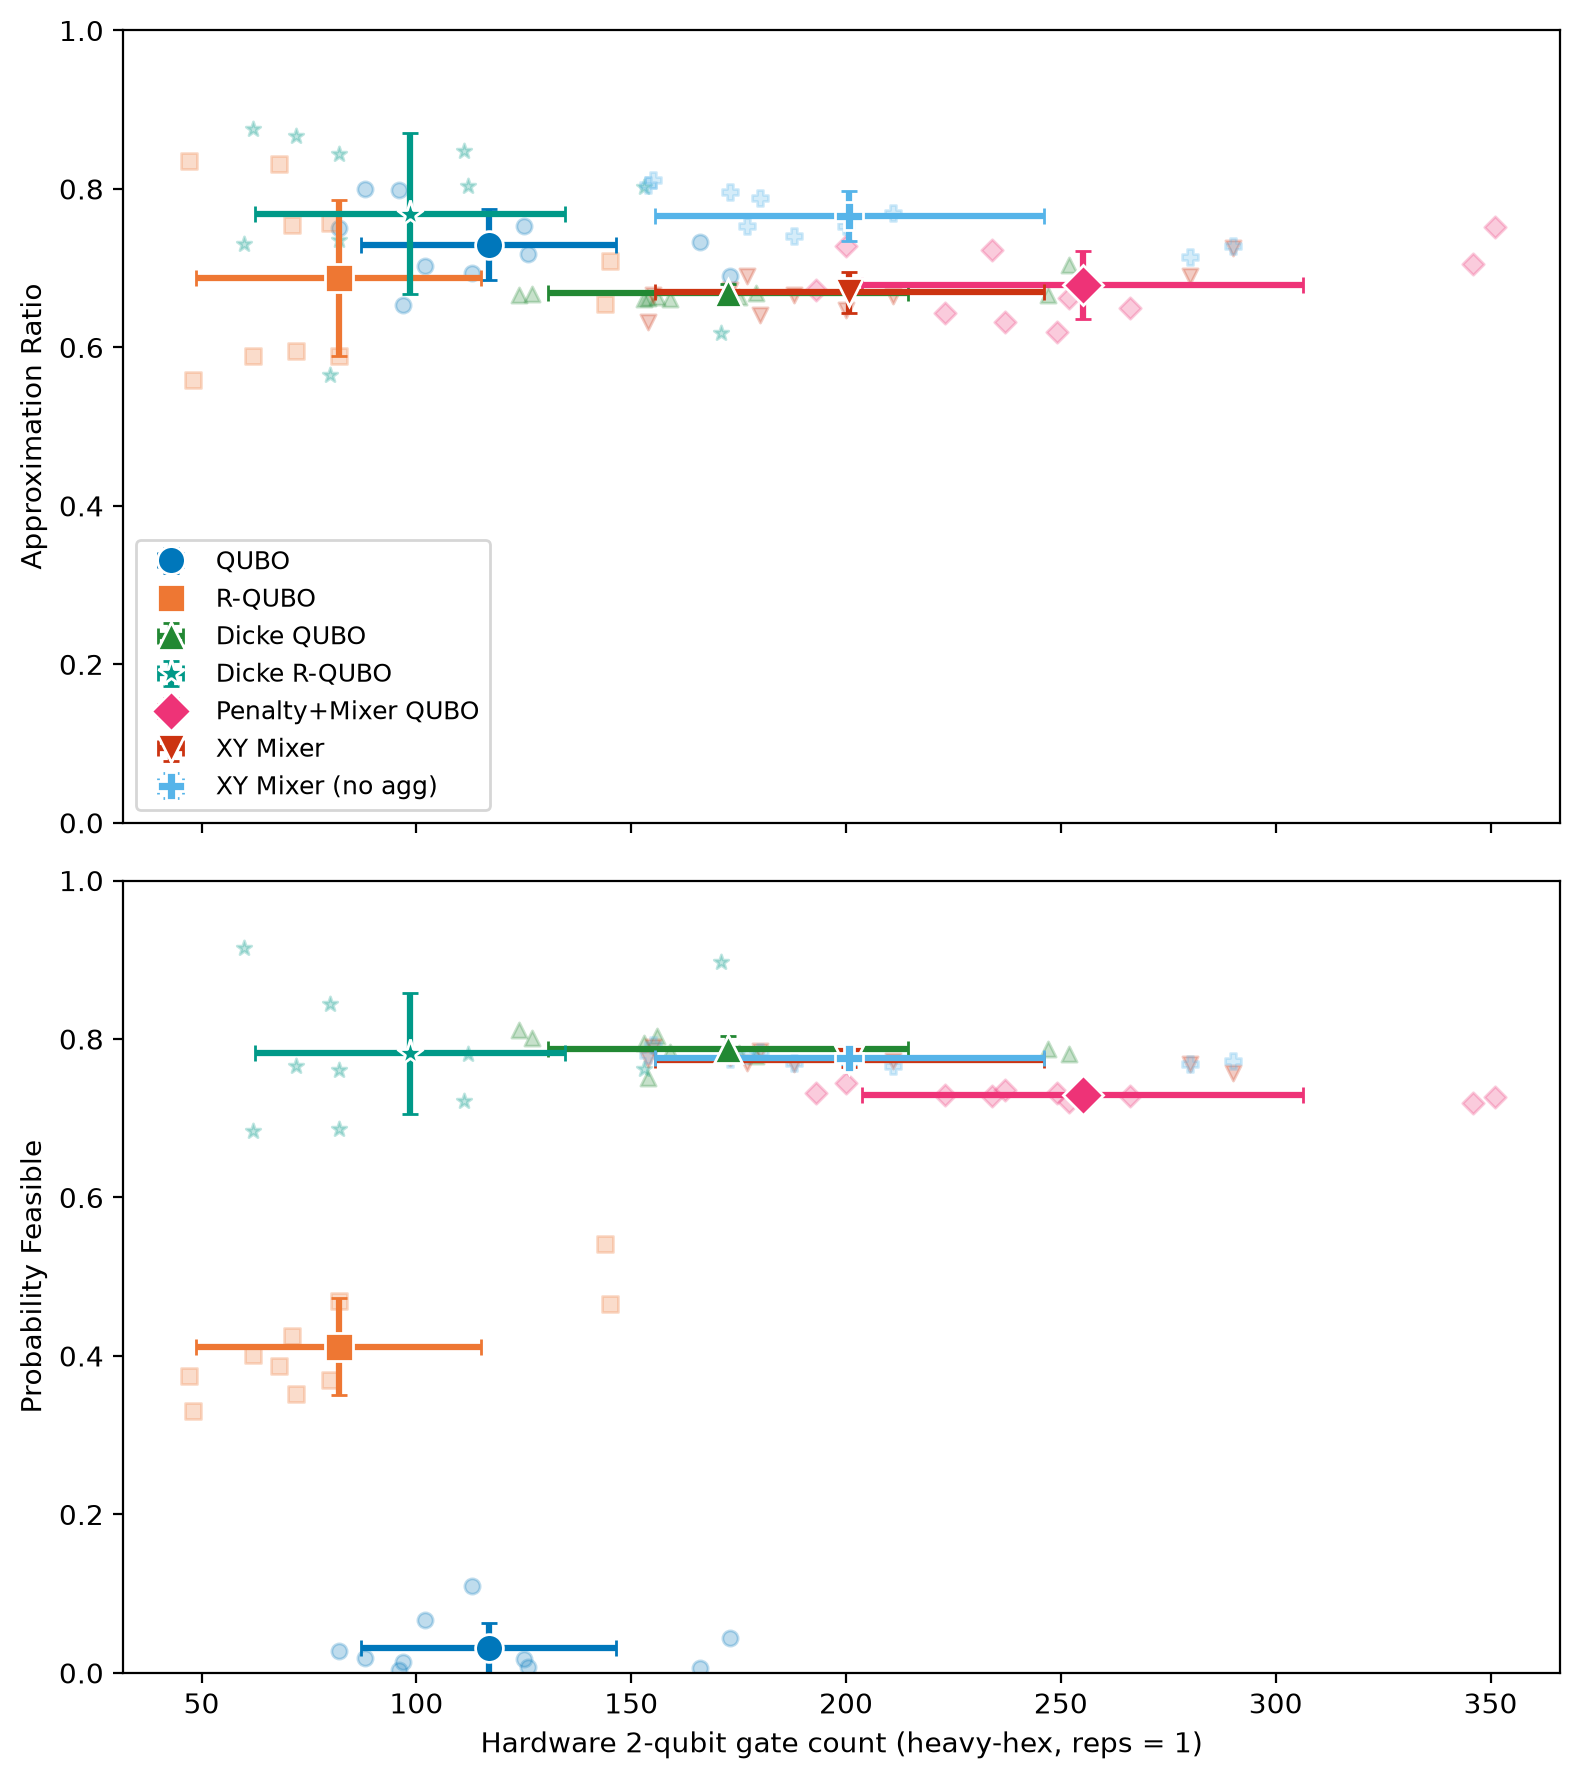

In [10]:
loaded_data_path = os.path.join(data_dir, f"{TAG}.npz")
if not os.path.exists(loaded_data_path):
    loaded_data_path = os.path.join(data_dir, "Noisy_Results_P1_random_init_10_graphs_cvar.npz")
loaded = np.load(loaded_data_path)
get = lambda key: loaded[key] if key in loaded else None

MARKERS = {"QUBO": "o", "R-QUBO": "s", "Dicke QUBO": "^", "Dicke R-QUBO": "*",
           "Penalty+Mixer QUBO": "D", "XY Mixer": "v", "XY Mixer (no agg)": "P"}

def spec(display, circuit_model, exp, feas):
    if exp is None:
        return None
    exp = exp[:, 0] if exp.ndim == 2 else exp        # (Tight) column
    feas = feas[:, 0] if feas.ndim == 2 else feas
    return (display, exp, feas, metrics[circuit_model]["hw_total"])

pareto = [s for s in [
    spec("QUBO", "QUBO", get("QUBO_EXP_VALS"), get("QUBO_FEASIBILITY")),
    spec("R-QUBO", "RQUBO", get("RQUBO_EXP_VALS"), get("RQUBO_FEASIBILITY")),
    spec("Dicke QUBO", "Dicke QUBO", get("DICKE_QUBO_EXP_VALS"), get("DICKE_QUBO_FEASIBILITY")),
    spec("Dicke R-QUBO", "Dicke RQUBO", get("DICKE_RQUBO_EXP_VALS"), get("DICKE_RQUBO_FEASIBILITY")),
    spec("Penalty+Mixer QUBO", "Penalty+Mixer QUBO",
         get("PENALTY_MIXER_QUBO_EXP_VALS"), get("PENALTY_MIXER_QUBO_FEASIBILITY")),
    spec("XY Mixer", "XY Mixer", get("XY_MIXER_EXP_VALS"), get("XY_MIXER_FEASIBILITY")),
    spec("XY Mixer (no agg)", "XY Mixer",
         get("XY_MIXER_NO_AGG_EXP_VALS"), get("XY_MIXER_NO_AGG_FEASIBILITY")),
] if s is not None]

fig, axs = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

for name, exp, feas, cost in pareto:
    color, mk = MODEL_COLORS[name], MARKERS[name]
    ok = exp != 0
    axs[0].scatter(cost[ok], exp[ok], color=color, marker=mk, alpha=0.25, s=30)
    axs[0].errorbar(cost[ok].mean(), exp[ok].mean(),
                    xerr=cost[ok].std(), yerr=exp[ok].std(),
                    fmt=mk, color=color, markersize=10, capsize=3,
                    markeredgecolor="white", label=name)
    axs[1].scatter(cost, feas, color=color, marker=mk, alpha=0.25, s=30)
    axs[1].errorbar(cost.mean(), feas.mean(),
                    xerr=cost.std(), yerr=feas.std(),
                    fmt=mk, color=color, markersize=10, capsize=3,
                    markeredgecolor="white")

axs[0].set_ylabel("Approximation Ratio")
axs[0].set_ylim(0, 1)
axs[0].legend(fontsize=9, loc="best")
axs[1].set_ylabel("Probability Feasible")
axs[1].set_ylim(0, 1)
axs[1].set_xlabel("Hardware 2-qubit gate count (heavy-hex, reps = 1)")

plt.tight_layout()
fig.savefig(os.path.join("Data", f"resource_pareto_{TAG}.pdf"), bbox_inches="tight")
plt.show()

## Caveats

- **ECR vs CX:** FakeBrisbane's native 2-qubit gate is ECR (CX-equivalent in 2-qubit
  cost); all counts filter on gate arity, not name.
- **Backend stand-in:** the noisy experiments used a noise model from the real
  `ibm_boston`; `qiskit-ibm-runtime` 0.33.2 has no fake counterpart, so FakeBrisbane
  (127-qubit heavy-hex Eagle) is used as the transpilation target.
- **Penalty value:** interaction structure is independent of $t$ except that isolated
  nodes drop their within-node penalty terms at $t=0$ (asserted above). Counts here
  are at $t=0$, matching the *(Tight)* quality data.
- **reps:** all numbers are for reps = 1. Cost- and mixer-layer counts scale linearly
  in reps; the initial state is a one-time cost.
- **Dicke prep:** `qc.initialize` decomposes with leading `reset`s (1-qubit,
  excluded from 2-qubit metrics by construction).
- **Segmentation barriers** prevent gate cancellation *across* segment boundaries
  during transpilation, so segmented hardware totals can slightly exceed a
  barrier-free transpile of the same circuit.